In [1]:
from database.db import supabase
import matplotlib.pyplot as plt
from matplotlib.axes import Axes
import numpy as np
from modeling.day_tags import get_adjustment_weight
import datetime as dt
from predict import default_k, default_knn_weights

In [2]:
from database.types import Movie, FirstDaysMultiRPC, BulkKNNRPC

movies_to_get = 50

movies: list[Movie] = (
    supabase.table("movie")
    .select("id, title")
    .lt("release_date", dt.datetime.now() - dt.timedelta(days=45))
    .gt("budget", 0)
    .order("release_date", desc=True)
    .limit(movies_to_get)
    .execute()
    .data
)

In [3]:
days_to_compare = 120

# get the first 60 box office days for each of the 10 knn'd movies
# use the first_days_multi rpc function
movie_ids = [movie["id"] for movie in movies]
movie_ids = ["70deef7a-03b7-4001-b91e-10ea3cb6eb7f", "0421bf53-3795-41e1-93fb-5ab2cbdadfa6", "a8ceb1ec-2f44-413e-b290-06ede35d42e7", "41342557-1869-4c23-b844-1fce4d05e652", "01c1a71a-a058-4b1c-a656-72af4176ab5f", "017967b6-cc2b-40eb-b763-062bdcd8abf9", "e3fa083c-f62b-4a90-b4a2-1e2119db42fb"]

first_days: list[FirstDaysMultiRPC] = (
    supabase.rpc("first_days_multi", {"movie_ids": movie_ids, "x": days_to_compare})
    .execute()
    .data
)

bulk_knn: list[BulkKNNRPC] = (
    supabase.rpc("bulk_knn", {"movie_ids": movie_ids, "restrict_before": True, "k": default_k(), "weights": default_knn_weights()})
    .execute()
    .data
)

knn_ids_set = set()

movie_to_knn: dict[str, list[str]] = {}

for movie in bulk_knn:
    if movie["similar_id"] not in movie_to_knn:
        movie_to_knn[movie["similar_id"]] = []
    movie_to_knn[movie["similar_id"]].append(movie["return_id"])
    knn_ids_set.add(movie["return_id"])

# then get the first_days_multi for all of these
knn_ids = list(knn_ids_set)

knn_first_days: list[FirstDaysMultiRPC] = (
    supabase.rpc("first_days_multi", {"movie_ids": knn_ids, "x": days_to_compare})
    .execute()
    .data
)

# get the titles for the knn movies
titles = (
    supabase.table("movie")
    .select("id, title")
    .in_("id", knn_ids + movie_ids)
    .execute()
    .data
)

In [4]:
for boxofficeday in first_days:
    date_obj = dt.datetime.strptime(boxofficeday["date"], "%Y-%m-%d").date()
    boxofficeday["adj_revenue"] = (
        boxofficeday["revenue"] / get_adjustment_weight(date_obj) 
    )

# adjust all of the days in knn_first_days
for boxofficeday in knn_first_days:
    date_obj = dt.datetime.strptime(boxofficeday["date"], "%Y-%m-%d").date()
    boxofficeday["adj_revenue"] = (
        boxofficeday["revenue"] / get_adjustment_weight(date_obj)
    )

In [5]:
movie_to_boxofficeday: dict[str, list[FirstDaysMultiRPC]] = {}

for boxofficeday in knn_first_days:
    if boxofficeday["return_id"] not in movie_to_boxofficeday:
        movie_to_boxofficeday[boxofficeday["return_id"]] = []
    movie_to_boxofficeday[boxofficeday["return_id"]].append(boxofficeday)


for boxofficeday in first_days:
    if boxofficeday["return_id"] in knn_ids_set:
        continue
    if boxofficeday["return_id"] not in movie_to_boxofficeday:
        movie_to_boxofficeday[boxofficeday["return_id"]] = []
    movie_to_boxofficeday[boxofficeday["return_id"]].append(boxofficeday)

# sort the box office days by date
for movie_id in movie_to_boxofficeday:
    movie_to_boxofficeday[movie_id].sort(key=lambda x: dt.datetime.strptime(x["date"], "%Y-%m-%d").date())

# movie id to title
movie_id_to_title: dict[str, str] = {}
for title in titles:
    movie_id_to_title[title["id"]] = title["title"]

In [33]:
def plot_boxoffice(boxofficedays: list[FirstDaysMultiRPC], knn_by_movie_id: dict[str, list[FirstDaysMultiRPC]], ax: Axes, var_name: str = 'revenue', days_to_plot: int = 120):
    title = movie_id_to_title[boxofficedays[0]["return_id"]]

    ax.plot(
        np.arange(len(boxofficedays)),
        [boxofficeday[var_name] / 1_000_000 for boxofficeday in boxofficedays],
        marker="o",
        label=title
    )

    # Plot the KNN data
    for bods in knn_by_movie_id.values():
        bod_title = movie_id_to_title[bods[0]["return_id"]]
        ax.plot(
            np.arange(len(bods)),
            [boxofficeday[var_name] / 1_000_000 for boxofficeday in bods],
            marker="x",
            label=bod_title,
            color="gray",
            alpha=0.3
        )

    ax.set(
        xlabel="Day of Release", ylabel="Box Office Revenue (in millions)",
    )
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.set_title(f"{'Adjusted' if var_name != 'revenue' else ''} Box Office Revenue Over Time for {title} vs Comps", fontsize=14)
    ax.legend(loc="upper right")
    ax.set_xlim(0, days_to_plot)

    return ax

def plot_multipliers(boxofficedays: list[FirstDaysMultiRPC], knn_by_movie_id: dict[str, list[FirstDaysMultiRPC]], ax: Axes, var_name: str = 'revenue', days_to_plot: int = 120):
    first_day_of_release = dt.datetime.strptime(boxofficedays[0]["date"], "%Y-%m-%d").date()
    first_weekday = first_day_of_release.weekday()
    days_to_skip = (4 - first_weekday) % 7
    movie_mults = [day[var_name] / boxofficedays[i - 1][var_name] for i, day in enumerate(boxofficedays[1:], 1)]
    movie_mults = movie_mults[days_to_skip:]
    title= movie_id_to_title[boxofficedays[0]["return_id"]]
    ax.plot(
        np.arange(len(movie_mults)),
        movie_mults,
        marker="o",
        label=title
    )

    mults_by_day: list[list[float]] = []
    for i in range(days_to_compare):
        mults_by_day.append([])

    # Plot the KNN data
    for bod in knn_by_movie_id.values():
        bod_title = movie_id_to_title[bod[0]["return_id"]]
        # include a bunch of 0 multipliers until the first friday -> saturday multiplier
        first_day_of_release = dt.datetime.strptime(bod[0]["date"], "%Y-%m-%d").date()
        first_weekday = first_day_of_release.weekday()
        days_to_skip = (4 - first_weekday) % 7
        mults = [day[var_name] / bod[i - 1][var_name] for i, day in enumerate(bod[1:], 1)]
        mults = mults[days_to_skip:]
        ax.plot(
            np.arange(len(mults)),
            mults,
            label=bod_title,
            color="gray",
            alpha=0.2
        )

        for i in range(days_to_compare):
            if len(mults) > i:
                mults_by_day[i].append(mults[i])

    # plot the medians
    medians = [np.median(mults) for mults in mults_by_day]
    ax.plot(
        np.arange(len(mults_by_day)),
        medians,
        marker="x",
        label="Median",
        color="orange",
        alpha=0.8
    )

    is_adjusted = var_name != "revenue"
    adjusted_str = "Adjusted " if is_adjusted else ""
    for i in range(len(movie_mults)):
        mapd = np.mean([abs((movie_mults[i] - medians[i]) / (movie_mults[i] + medians[i])) for i in range(i)])

        if i % 10 == 0 and i > 0:
            print(f"{adjusted_str}MAPD vs median: {mapd} for day {i} of {title}")

    # plot the means
    # plt.plot(
    #     np.arange(len(mults_by_day)),
    #     [np.mean(mults) for mults in mults_by_day],
    #     marker="o",
    #     label="Mean",
    #     color="purple",
    #     alpha=0.5
    # )

    ax.axhline(1, color="red", linestyle="--", label="1")

    ax.set_ylim(min(movie_mults) * 0.5, max(movie_mults) * 1.1)
    ax.tick_params(axis='both', which='major', labelsize=12)
    # increase font size of x and y labels
    ax.set_xlabel("Day of Release", fontsize=18)
    ax.set_ylabel("Multiplier", fontsize=18)
    ax.set_title(f"{adjusted_str}Box Office Multiplier Over Time for {title} vs Comps", fontsize=20)
    ax.legend(loc="upper right", fontsize=14)
    ax.set_xlim(0, days_to_plot)
    return ax

MAPD vs median: 0.038363621011034986 for day 10 of Conclave
MAPD vs median: 0.05489858334336824 for day 20 of Conclave
MAPD vs median: 0.0594676947094219 for day 30 of Conclave
MAPD vs median: 0.06877005846056221 for day 40 of Conclave
MAPD vs median: 0.07440043582460826 for day 50 of Conclave
MAPD vs median: 0.08058744168786965 for day 60 of Conclave
MAPD vs median: 0.08967772169367735 for day 70 of Conclave
MAPD vs median: 0.09177988988996902 for day 80 of Conclave
MAPD vs median: 0.1028426494874397 for day 90 of Conclave
MAPD vs median: 0.11495782207719633 for day 100 of Conclave
MAPD vs median: 0.12102761422164064 for day 110 of Conclave


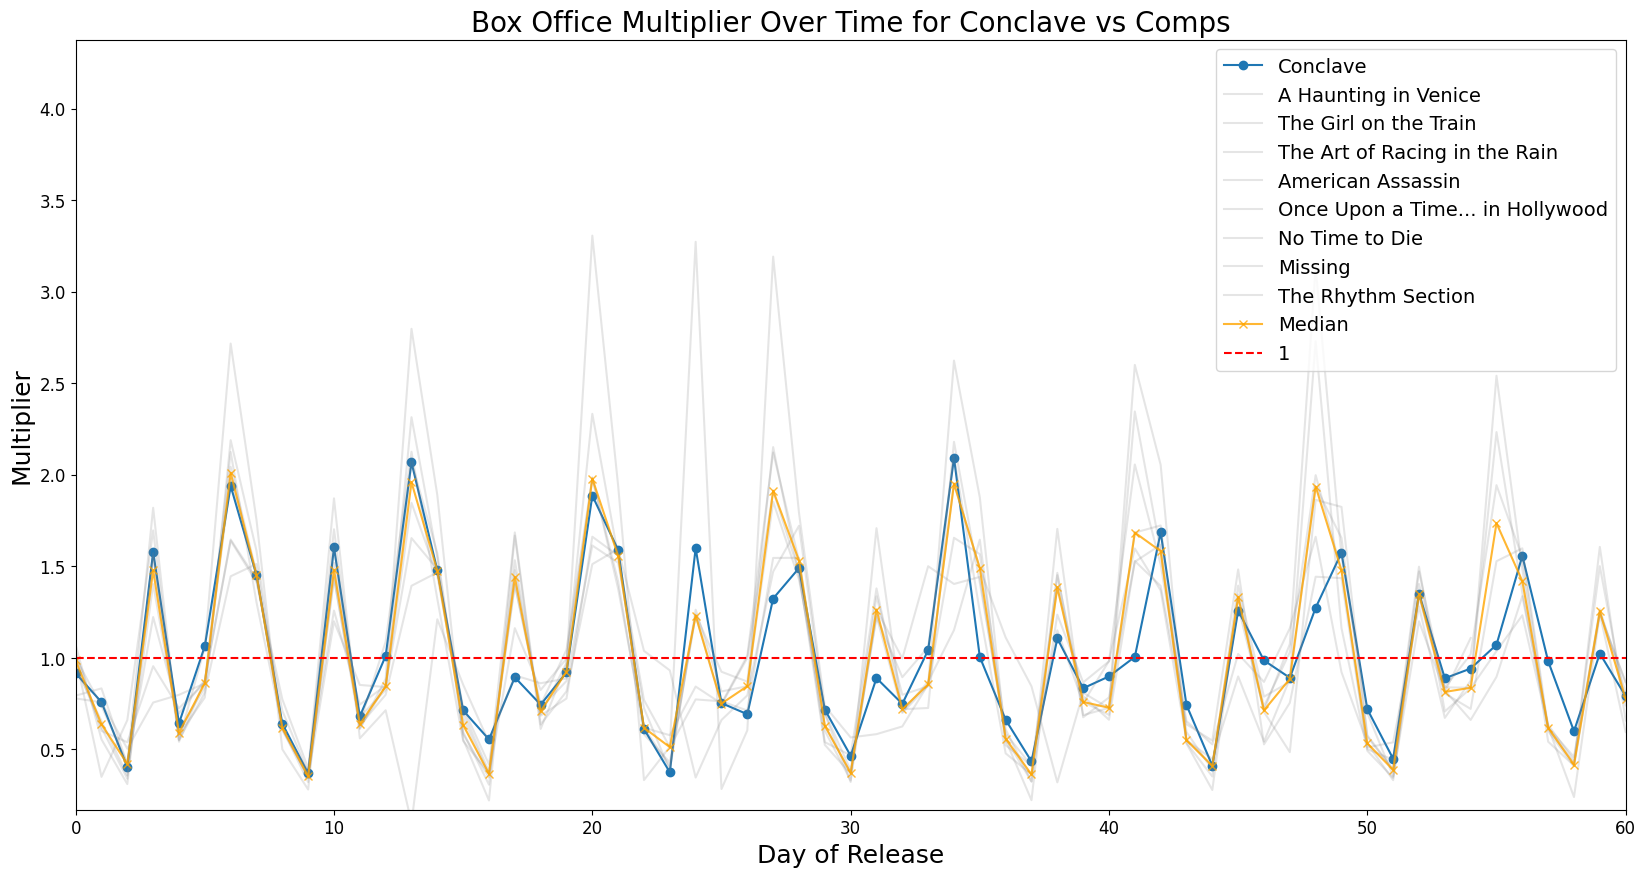

In [34]:
# plot just the multipliers for Conclave for 60 days
fig, ax = plt.subplots(1, 1, figsize=(20, 10))
movie_to_plot_id = movie_ids[0]

boxofficedays = movie_to_boxofficeday[movie_to_plot_id]
knn_by_movie_id = {}
for movie in movie_to_knn[movie_to_plot_id]:
    knn_by_movie_id[movie] = movie_to_boxofficeday[movie]
ax = plot_multipliers(
    boxofficedays,
    knn_by_movie_id,
    ax,
    days_to_plot=60
)

In [ ]:
for movie_to_plot_id in movie_ids:
    boxofficedays = movie_to_boxofficeday[movie_to_plot_id]
    knn_by_movie_id = {}
    for movie in movie_to_knn[movie_to_plot_id]:
        knn_by_movie_id[movie] = movie_to_boxofficeday[movie]

    first_2 = True

    if first_2:
        figure, ax = plt.subplots(2, figsize=(18, 10))
        plot_boxoffice(boxofficedays, knn_by_movie_id, ax[0])
        plot_multipliers(boxofficedays, knn_by_movie_id, ax[1])
    else:
        figure, ax = plt.subplots(4, figsize=(18, 20))
        plot_boxoffice(boxofficedays, knn_by_movie_id, ax[0])
        plot_multipliers(boxofficedays, knn_by_movie_id, ax[1])
        plot_boxoffice(boxofficedays, knn_by_movie_id, ax[2], var_name="adj_revenue")
        plot_multipliers(boxofficedays, knn_by_movie_id, ax[3], var_name="adj_revenue")
    plt.show()

In [8]:
# ok now goal is to do some sort of gradient descent to find the best weights for the KNN